# **--- WALMART PROJECT---** #

Walmart Inc. is an American multinational retail corporation that operates a chain of hypermarkets, discount department stores, and grocery stores from the United States. The goal of this project is to understand how the sales are influenced by economic indicators by using linear regression models and optimization.

## **I. Explanatory Data Analysis (EDA)** ##

### **1. Libraries import** ###

In [504]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from scipy.stats import ttest_ind

### **2. Data import and first observations** ###

In [505]:
raw_df = pd.read_csv("DATA/Data_raw/Walmart_Store_sales.csv")
raw_df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


In [506]:
print(f"The dataset has : \n - {raw_df.shape[0]} rows,\n - {raw_df.shape[1]} columns.")

The dataset has : 
 - 150 rows,
 - 8 columns.


In [507]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         150 non-null    float64
 1   Date          132 non-null    object 
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  138 non-null    float64
 4   Temperature   132 non-null    float64
 5   Fuel_Price    136 non-null    float64
 6   CPI           138 non-null    float64
 7   Unemployment  135 non-null    float64
dtypes: float64(7), object(1)
memory usage: 9.5+ KB


We can observe that some columns have missing values. Moreover, the "Date" column will have to be transformed into a datetime object.

In [508]:
raw_df.describe(include="all")

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,132,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
unique,NaN,85,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,19-10-2012,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
mean,9.866667,NaN,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,NaN,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,NaN,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,NaN,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,NaN,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,NaN,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000


In [509]:
raw_df["Store"].value_counts()

Store
3.0     15
1.0     11
18.0    10
19.0     9
5.0      9
14.0     9
13.0     9
7.0      8
17.0     8
2.0      8
8.0      8
6.0      7
20.0     7
4.0      7
12.0     5
10.0     5
15.0     4
16.0     4
9.0      4
11.0     3
Name: count, dtype: int64

In [510]:
nb_stores = len(raw_df["Store"].unique())
print(f"There are {nb_stores} in the dataset.")

There are 20 in the dataset.


The column "Store" does not correspond to unique identifiers for each store. We have several records for the same stores numbers so this column should not be deleted. But it is used to caracterize the number of the store so we will transform this variable as a categorical variable.

In [511]:
raw_df["Holiday_Flag"].value_counts()

Holiday_Flag
0.0    127
1.0     11
Name: count, dtype: int64

The variable Holiday_Flag correspond to a boolean variable so will have to change its type.

### **3. Prepare data for explanatory analysis** ###

**3.1. Types modification**

We have seen previously that "Holiday_Flag" needs to be considered as a boolean and "Date" as a datetime. Moreover, "Store" should be treated as a categorical variable.

In [512]:
# We transform the variable Holiday_Flag into a boolean 0/1
raw_df["Holiday_Flag"] = raw_df["Holiday_Flag"].astype("boolean")

# We transform the variable Date into a DateTime format
raw_df["Date"] = pd.to_datetime(raw_df["Date"], format="%d-%m-%Y")

# We transform "Store" as a categorical variable
raw_df["Store"] = raw_df["Store"].astype(int).astype("category")

**3.2 Separating variables according to types**

In [513]:
# Identify the target:
target="Weekly_Sales"
target_col = raw_df[target]

# Separating the variables per type :
num_col = raw_df.select_dtypes(include="float64").copy().drop(columns=target)
cat_col = raw_df.select_dtypes(include="category").copy()
bool_col = raw_df.select_dtypes(include="boolean").copy()
date_col = raw_df.select_dtypes(include="datetime64[ns]").copy()

# Lists of column names : 
num_col_names = num_col.columns.to_list()
cat_col_names = cat_col.columns.to_list()
bool_col_names = bool_col.columns.to_list()
date_col_names = date_col.columns.to_list()

**3.3. Analyzing duplicates**

In [514]:
# Check for duplicates
nb_duplicates = raw_df.duplicated().sum()
print(f"There are {nb_duplicates} duplicated rows in the dataset.")

There are 0 duplicated rows in the dataset.


**3.4. Analyzing missing values**

In [515]:
print("Number of missing values per variable : \n")
for col in raw_df.columns:
    nb_missing = raw_df[col].isna().sum()
    percentage_missing = round(100*nb_missing/raw_df.shape[0],2)
    print(f"- {col} : {nb_missing} missing values ({percentage_missing} % of total rows)")

Number of missing values per variable : 

- Store : 0 missing values (0.0 % of total rows)
- Date : 18 missing values (12.0 % of total rows)
- Weekly_Sales : 14 missing values (9.33 % of total rows)
- Holiday_Flag : 12 missing values (8.0 % of total rows)
- Temperature : 18 missing values (12.0 % of total rows)
- Fuel_Price : 14 missing values (9.33 % of total rows)
- CPI : 12 missing values (8.0 % of total rows)
- Unemployment : 15 missing values (10.0 % of total rows)


We observed missing values for all variables except `Store`. When possible, we will prefer imputation instead of deleting (small dataset and missing values <12%). We will adopt different strategies according to the variables: 

- **For the target**: We cannot use imputation techniques on the target (it might create some bias in the predictions) so we will drop all rows for which the value in `Weekly_Sales` is missing.

- **For the dates** (`Date`): Dates cannot be easily imputed so we will delete rows with empty dates.

- **For numerical features** (`Temperature`, `Fuel_Price`, `CPI`, `Unemployment`): use a SimpleImputer (with the median strategy : more robust than the mean),

- **For boolean features** (`Holiday_Flag`): Impute according to the most frequent value (mode).



In [516]:
# Drop rows for variables that cannot be imputed:
df = raw_df.dropna(subset=["Weekly_Sales"])
df = df.dropna(subset=["Date"])

nb_deleted = raw_df.shape[0]-df.shape[0]
print(f"After dropping: {df.shape[0]} remaining columns\n({nb_deleted} rows have been deleted : {round(100*nb_deleted/raw_df.shape[0],2)} % of the initial number of rows).")

After dropping: 118 remaining columns
(32 rows have been deleted : 21.33 % of the initial number of rows).


In [517]:
# Impute numerical features with the median:
imputer_num = SimpleImputer(strategy='median')
df[num_col_names] = imputer_num.fit_transform(df[num_col_names])

In [518]:
# Impute boolean feature with the mode:
imputer_bool = SimpleImputer(strategy='most_frequent')
df[bool_col_names] = imputer_bool.fit_transform(df[bool_col_names])

In [519]:
# Final check:
print(f"Number of missing values:\n{df.isnull().sum().sum()}")
print(f"\nFinal shape after dealing with missing values: {df.shape}")

Number of missing values:
0

Final shape after dealing with missing values: (118, 8)


Now `df` is complete without any missing values.

**3.5 Analyzing outliers**

In this project, will be considered as outliers all the numeric features that do not fall within the range : [Xˉ−3σ,Xˉ+3σ]. This concerns the columns : `Temperature`, `Fuel_price`, `CPI` and `Unemployment`.

In [520]:
for col in num_col_names:
    mean = df[col].mean()
    std = df[col].std()
    df = df[(df[col] >= mean - 3*std) & (df[col] <= mean + 3*std)]

In [521]:
print(f"\nFinal shape of the dataset after dealing with ouliers: {df.shape}.\n ")


Final shape of the dataset after dealing with ouliers: (113, 8).
 


**3.6 Create new features and drop useless column**

In [522]:
# We create new columns that might be useful to study the seasonal effects
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

In [523]:
# We do not need the column 'Date' anymore, we can drop it:
df = df.drop("Date", axis=1)

### **4. EDA** ###

**4.1. Analyzing distributions**

*4.1.1. Target distribution*

<Axes: xlabel='Weekly_Sales', ylabel='Count'>

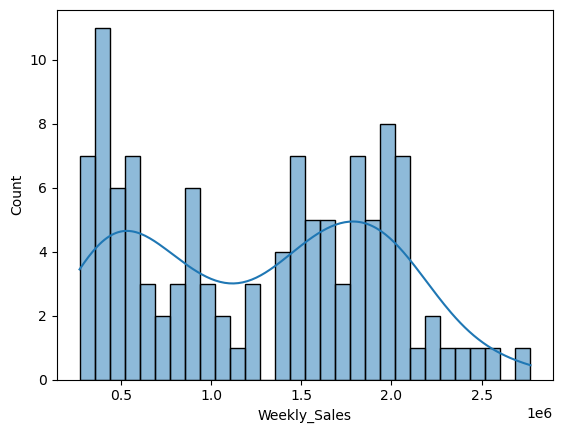

In [524]:
sns.histplot(df[target], bins=30, kde=True)

It seems that we have two main groups of weekkly sales (one around 0,4e6 and one around 1,7e6) (multimodal distribution).

*4.1.2. Numerical features distributions*

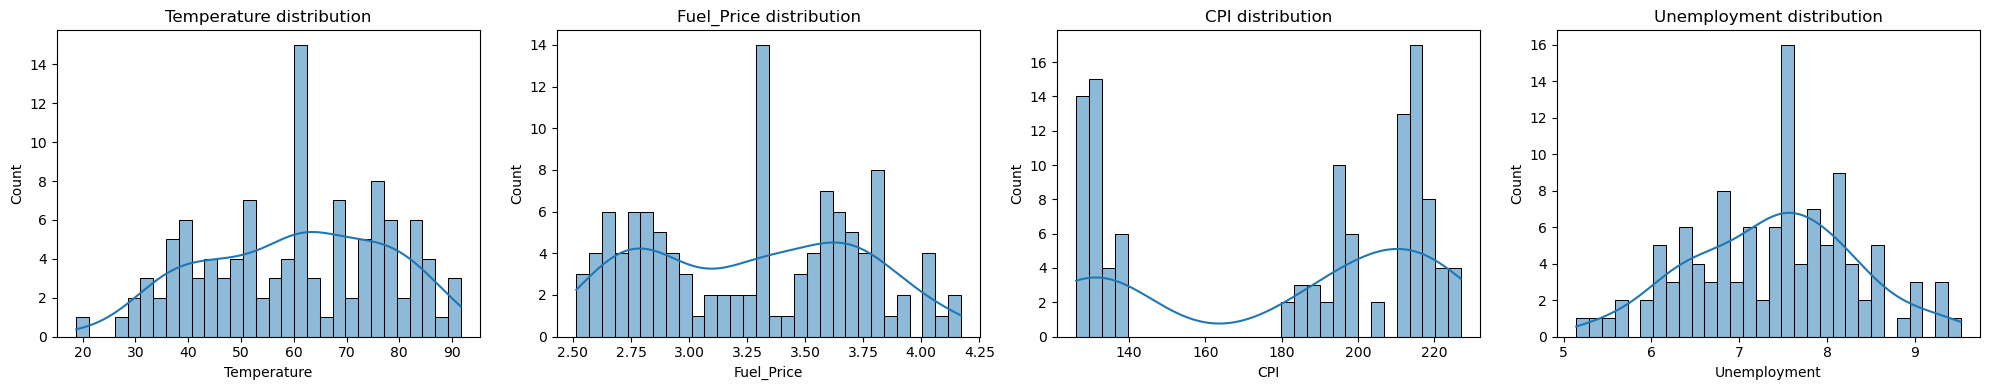

In [525]:
fig, ax = plt.subplots(nrows=1, ncols=len(num_col_names), figsize=(5 * len(num_col_names), 4))

for i, col in enumerate(num_col_names):
    sns.histplot(df[col], bins=30, kde=True, ax=ax[i])
    ax[i].set_title(f"{col} distribution")

plt.tight_layout()
plt.show()

The `Temperature` and `Unemployment` variables have a "bell" distrubution whereas the `Fuel_price`and `CPI` seem to have a bimodal distribution.

*4.1.3. Boolean feature distribution*

In [526]:
fig = px.histogram(df, x="Holiday_Flag", width = 400, height=400, text_auto=True, histnorm="percent")
fig.update_traces(
    texttemplate="%{y:.2f}%",
)
fig.show()

We have a clear imbalanced variable with rare `Holiday_Flag` values equal to 1. There are more "normal days" (`Holiday_Flag`= 0) than "holidays" (`Holiday_Flag`= 1).

In [527]:
# Sales for each case (Holiday / Normal day)
print(df.groupby("Holiday_Flag")["Weekly_Sales"].describe())

              count          mean            std        min          25%  \
Holiday_Flag                                                               
0.0           106.0  1.262128e+06  680626.155039  268929.03  539841.1125   
1.0             7.0  1.347476e+06  618156.725867  563460.77  796338.9750   

                      50%          75%         max  
Holiday_Flag                                        
0.0           1412706.425  1855008.015  2771397.17  
1.0           1641957.440  1778490.150  2077256.24  


The mean and median are higher for the sales occuring during Holidays (we need a statistical test in order to check the significance of this result).

*4.1.4. Categorical feature distribution*

<Axes: xlabel='Store', ylabel='count'>

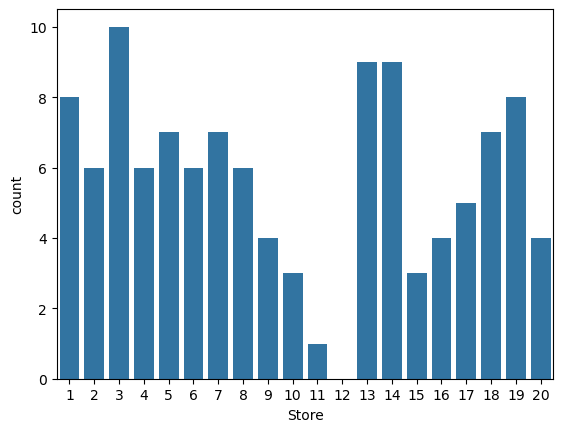

In [528]:
# Number of sales per store 
sns.countplot(data=df,x=df["Store"])

The distribution of weekly sales is not equivalent for all stores, some have 10 records (store N°3) while ohters have 1 or 0 records (Stores N°11 and 12). This difference might be explained by the difference of size of the stores.

*4.1.5. Time values distribution*

In [529]:
for period in ["Year","Month","Day","DayOfWeek"]:
    print(f"{period} : {len(df[period].unique())}")

Year : 3
Month : 12
Day : 30
DayOfWeek : 1


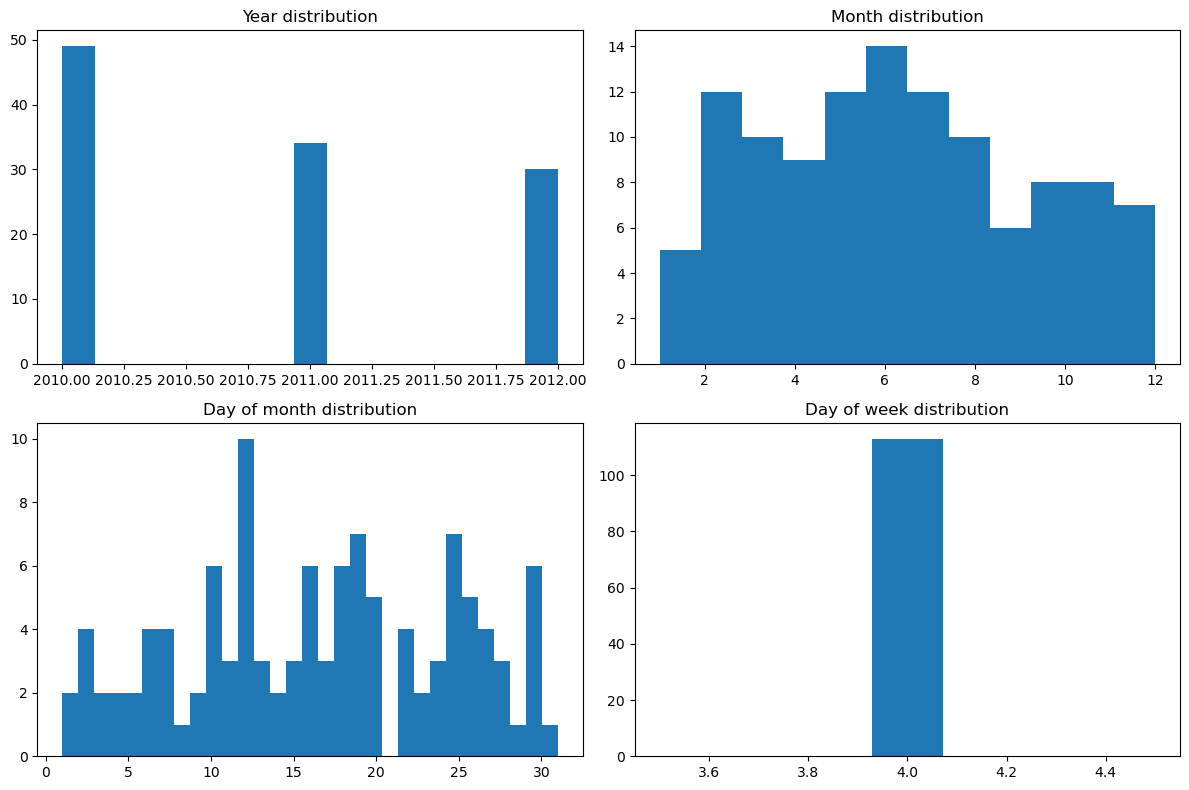

In [530]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0,0].hist(df["Year"], bins=15)
ax[0,0].set_title("Year distribution")

ax[0,1].hist(df["Month"], bins=12)
ax[0,1].set_title("Month distribution")

ax[1,0].hist(df["Day"], bins=31)
ax[1,0].set_title("Day of month distribution")

ax[1,1].hist(df["DayOfWeek"], bins=7)
ax[1,1].set_title("Day of week distribution")

plt.tight_layout()
plt.show()

According to this dataset, we have weekly sales records for 3 different years (2010 to 2012), the sales are more important in March, June and October with a pick in June. The lowest months are January and September. The sales are spread around all days of the month with a pick around the 12th and no sales on the 21st. What brings our attention is that the sales records are all done the 4th days of the week (likely due to fixed reporting timing). This will create aperfect multicolinearity, we need to delete this variable. 

In [531]:
df = df.drop("DayOfWeek", axis=1)

**4.2. Analysis of relationships between variables**

*4.2.1. Relationship between numerical predictors*

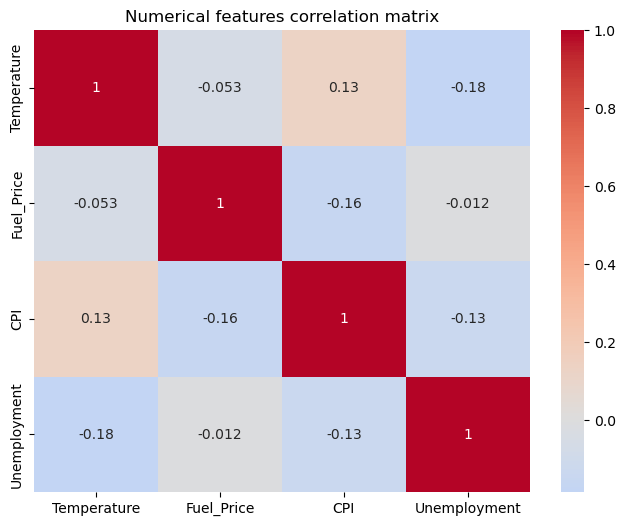

In [532]:
corr_matrix = df[num_col_names].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True)
plt.title("Numerical features correlation matrix")
plt.show()

We can observe that the correlations between variables are really low (<0,2))

*4.2.2. Relashionship between numerical features and the target*

In [533]:
# Correlation with the target
corr_with_target = df[num_col_names + [target]].corr()[target].sort_values(ascending=False)
print("\nCorrelation with Weekly_Sales:")
print(corr_with_target)


Correlation with Weekly_Sales:
Weekly_Sales    1.000000
Unemployment    0.165077
Fuel_Price     -0.017889
Temperature    -0.187951
CPI            -0.313061
Name: Weekly_Sales, dtype: float64


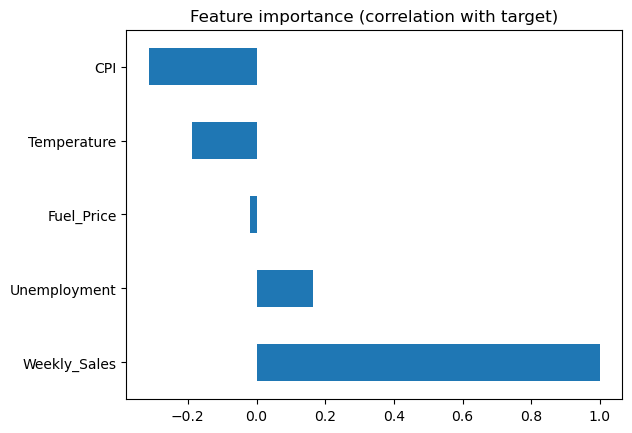

In [534]:
corr_with_target.plot(kind='barh')
plt.title("Feature importance (correlation with target)")
plt.show()

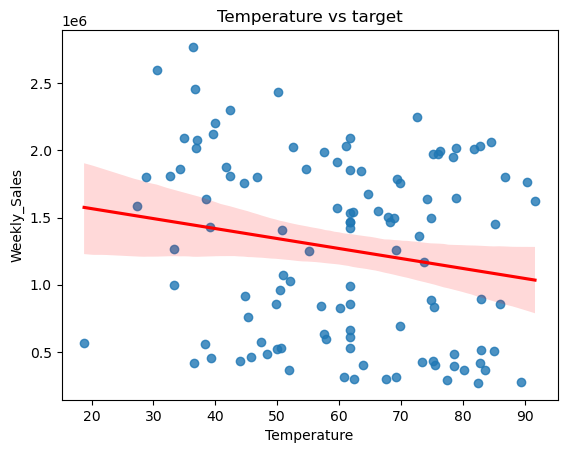

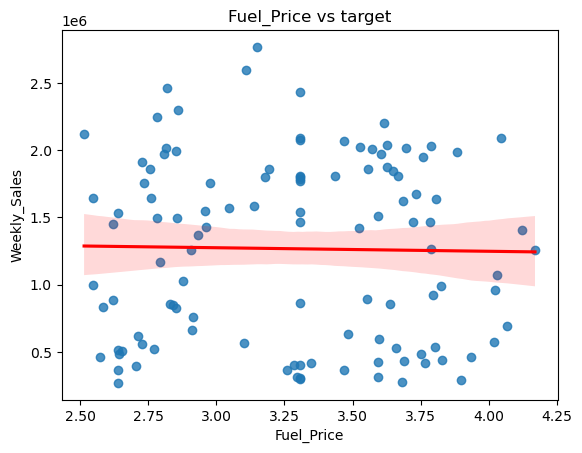

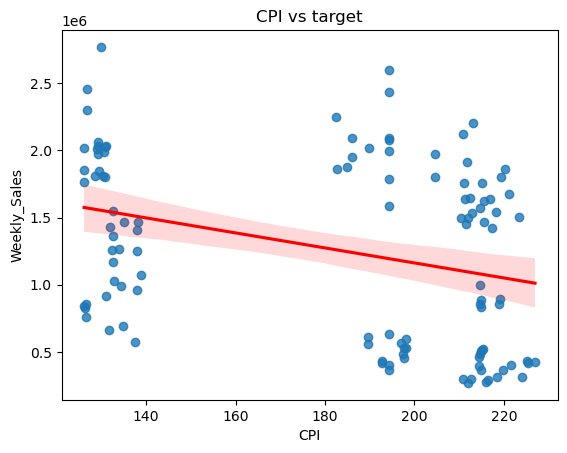

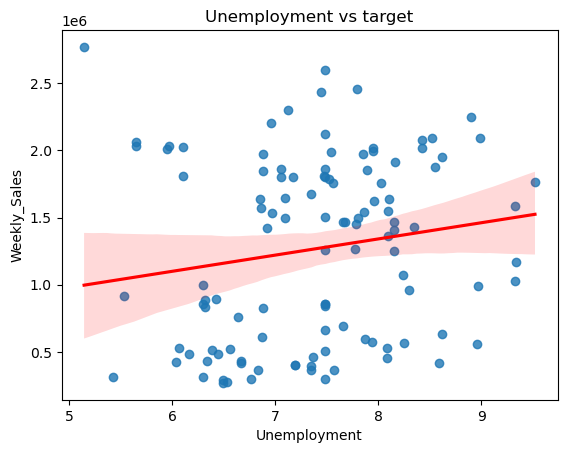

In [535]:
for num_col in num_col_names:
    sns.regplot(x=df[num_col], y=df[target], fit_reg=True,line_kws={"color": "red"})
    plt.title(f"{num_col} vs target")
    plt.show()

It seems that Weakly_Sales decrease when the `Temperature` or the `CPI` increase (negative correlation). This is the opposite for the `Unemployment` (positive correlation). And the sales does not seem to be impacted by the fuel prices (no correlation). 

*4.2.3. Relashionship between boolean feature and the target*

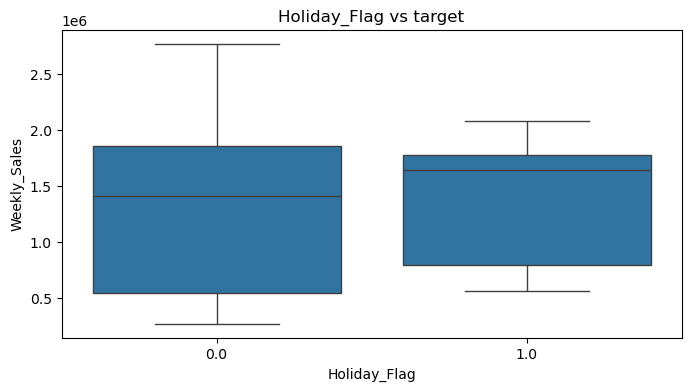

In [536]:
for bool_col in bool_col_names:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[bool_col], y=df[target])
    plt.title(f"{bool_col} vs target")
    plt.show()

It seems that the Holidays might have a positive impact on Weekly_Sales. We will aply a statistical test to check if this difference is signigicant.

In [537]:
group_0 = df[df["Holiday_Flag"] == 0]["Weekly_Sales"]
group_1 = df[df["Holiday_Flag"] == 1]["Weekly_Sales"]
t_stat, p_value = ttest_ind(group_0, group_1)

print(f"\nt-test p-value: {p_value}")
print("Is the difference significant?" + (" Yes." if p_value < 0.05 else " No."))


t-test p-value: 0.7474082333065476
Is the difference significant? No.


This difference is not significant.

## **5. Insights from EDA** ##


1. TARGET (Weekly_Sales):
   - Distribution: BIMODAL (two distinct groups)
   - Implication: May be related to store size

2. NUMERICAL FEATURES:
   - Inter-feature correlations: Very low (< 0.2): No multicollinearity
   - Correlations with target:
     * Temperature: negative correlation
     * CPI: negative correlation  
     * Unemployment: positive correlation
     * Fuel_Price: almost no correlation

3. BOOLEAN FEATURE (Holiday_Flag):
   - Imbalanced: 93,8% regular days, 6,2% holidays
   - T-test p-value > 0.05: Difference NOT statistically significant
   - However, mean/median are higher during holidays

4. STORES:
   - Uneven distribution: Some stores have 10 records, others 0–1
   - Likely due to differences in store size

5. OUTLIERS:
   - {outlier_count} observations removed
   - Remaining: {df.shape[0]} observations

In [538]:
df.to_csv("DATA/Data_cleaned/Walmart_clean_dataset.csv", index=False)
print(f"Cleaned dataset saved: \n  - Final shape: {df.shape}\n  - Final features: {df.columns.tolist()}")

Cleaned dataset saved: 
  - Final shape: (113, 10)
  - Final features: ['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day']


## **II. Models** ##

### **1. Preprocessing** ###

**1.1. Train test split**

To avoid data leakage, we need to divide our dataset into Train and Test sets before any transformation.

In [539]:
y = df[target]
X = df.drop(target, axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Train set: (90, 9)
Test set: (23, 9)


**1.2. Column transformer**

We will and StandardScaler the numerical features (to avoid to have an impact of the difference of scales between features). Moreover we will OneHotEncode the categorical feature (to have categories represented with 0 and 1). The boolean feature will be considered as a catecory in our pipeline.

In [540]:
# Variables identification
cat_features = ["Store", "Holiday_Flag"] 
num_features = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "Year", "Month", "Day"]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features) # spare : Dense array, easier to manipulate
    ]
)

### **2. Baseline model** ###

Now that our preprocessor is created, we can use it in the pipeline to train the linear regression model.

In [541]:
# Create the pipeline
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train
baseline_model.fit(X_train, y_train)

# Predict
y_train_pred = baseline_model.predict(X_train)
y_test_pred = baseline_model.predict(X_test)

To evaluate this model we will use R² (%variance explained by the model :  should be closed to 1) and RMSE (Root Mean Squared Error, best when close to 0).

In [542]:
# R² Score
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

In [543]:
print("Evaluation metrics\n")
print("R² Score (higher is better):")
print(f"  - Train R² : {r2_train:.4f}")
print(f"  - Test R²  : {r2_test:.4f}")
print(f"Difference: {r2_train - r2_test:.4f} (overfitting indicator)")

print("\nRMSE (lower is better) in dollars:")
print(f"  - Train RMSE : ${rmse_train:,.2f}")
print(f"  - Test RMSE  : ${rmse_test:,.2f}")
print(f"Difference : ${rmse_train - rmse_test:,.2f}")

Evaluation metrics

R² Score (higher is better):
  - Train R² : 0.9754
  - Test R²  : 0.9322
Difference: 0.0432 (overfitting indicator)

RMSE (lower is better) in dollars:
  - Train RMSE : $108,615.93
  - Test RMSE  : $151,718.53
Difference : $-43,102.60


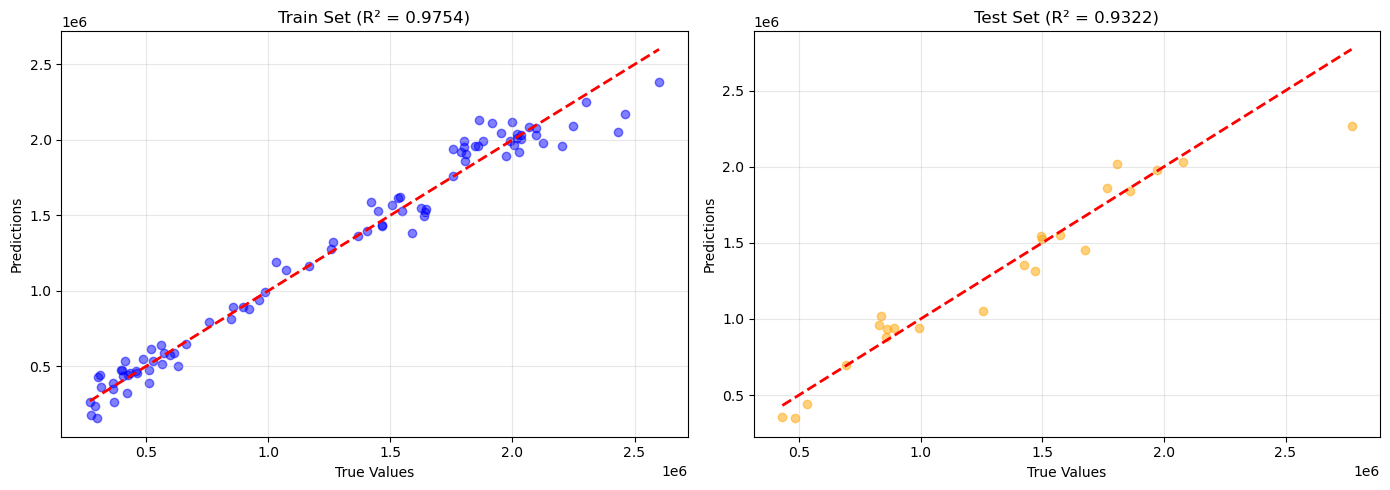

In [544]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train set
axes[0].scatter(y_train, y_train_pred, alpha=0.5, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('True Values')
axes[0].set_ylabel('Predictions')
axes[0].set_title(f'Train Set (R² = {r2_train:.4f})')
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.5, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('True Values')
axes[1].set_ylabel('Predictions')
axes[1].set_title(f'Test Set (R² = {r2_test:.4f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

R²_train and R²_test are >0,9 so our baseline is already quite good. The difference between them is <0,1 so the overfitting is already low (lickly thanks to the cleaning process during the EDA phase). Now, let's identify the features of importance :

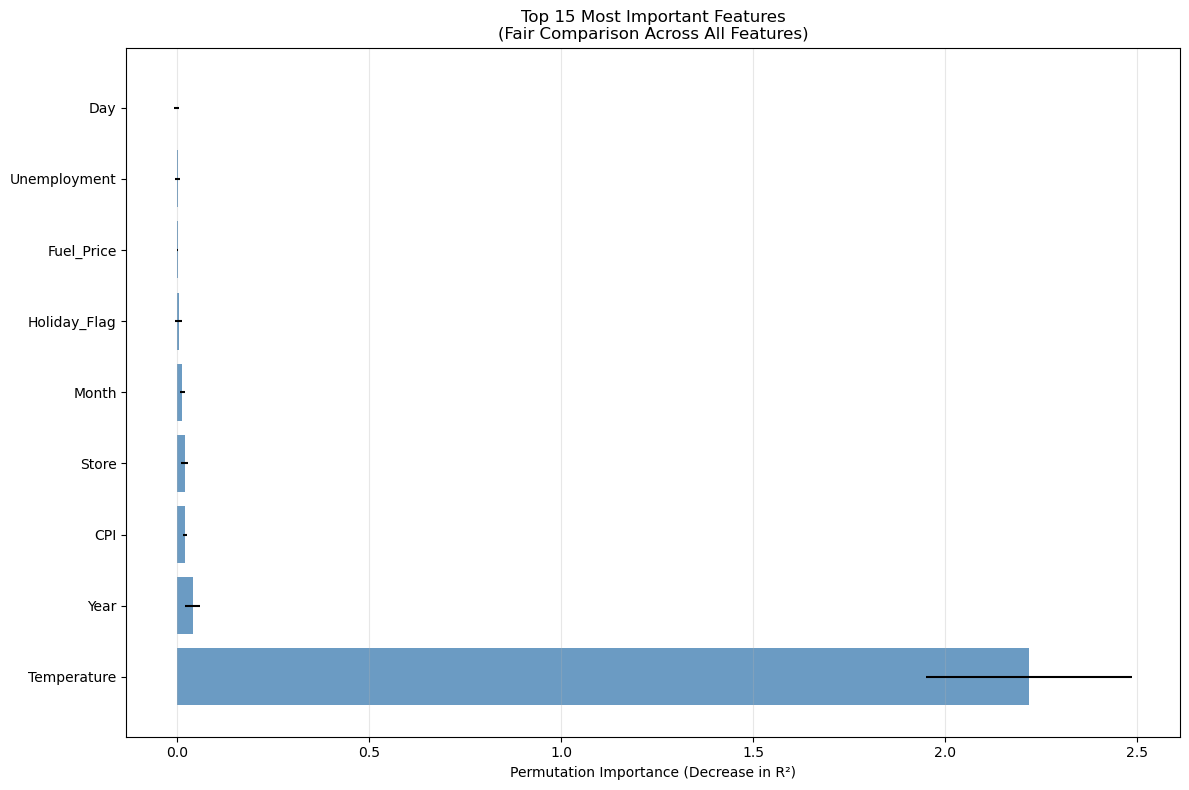


Top 15 Features by Permutation Importance:
     Feature  Importance
 Temperature    2.219493
        Year    0.040554
         CPI    0.021169
       Store    0.019550
       Month    0.013423
Holiday_Flag    0.004240
  Fuel_Price    0.000974
Unemployment    0.000712
         Day   -0.001913


In [ ]:
# Get original features names (before preprocessing)
original_feature_names = num_features + cat_features

# Calculate permutation importance
perm_importance = permutation_importance(
    baseline_model, 
    X_test, 
    y_test, 
    n_repeats=10,
    random_state=42,
    n_jobs=1
)

# Create dataframe with the original names
importance_df = pd.DataFrame({
    'Feature': original_feature_names,  # ← CHANGEMENT
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))
top_features = importance_df.head(15)

ax.barh(top_features['Feature'], top_features['Importance'], 
        xerr=top_features['Std'], color='steelblue', alpha=0.8)
ax.set_xlabel('Permutation Importance (Decrease in R²)')
ax.set_title('Top 15 Most Important Features\n(Fair Comparison Across All Features)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTop Features by Permutation Importance:")
print(importance_df[['Feature', 'Importance']].head(15).to_string(index=False))

Based on permutation importance analysis, we identified that temperature i by far the most critical predictor. We can imagine that weather conditions frive costumers to buy seasonal products. The secondary driver is the Year and then the CPI (inflation moderately impacts consumer purchasing power, with higher inflation correlating to reduced sales.). The other factors are negligeable to explain the model.

Althought our baseline model is already quite good, let's try to improve it with a regularization method.

### **3. Optimization** ###

During the EDA phase, we observed a realy low correlation between features (<0,2) so we will use the Lasso regulation (to do a feature selection). We will also use a GridSeachCV to find the best parameters.

In [546]:
# Create a new preprocessor for Lasso (to avoid data leakage)
preprocessor_lasso = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(
            drop='first', 
            sparse_output=False,
            handle_unknown='ignore' # To avoid problems of folds with a missing category
            ), cat_features)
    ]
)

# Hyperparameter grid
lasso_param_grid = {'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

# GridSearchCV with Lasso
lasso_model = Lasso(max_iter=5000)
lasso_grid_search = GridSearchCV(
    estimator=Pipeline(steps=[
        ('preprocessor', preprocessor_lasso),
        ('model', lasso_model)
    ]),
    param_grid=lasso_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=1,
    verbose=0  # Set to 0 for cleaner output
)

lasso_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Temperature',
                                                                          'Fuel_Price',
                                                                          'CPI',
                                                                          'Unemployment',
                                                                          'Year',
                                                                          'Month',
                                                                          'Day']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['Store',
                                                                          'Holiday_Flag'])])),
                                       ('model', Lasso(max_iter=5000))]),
             n_jobs=1,
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             scoring='r2')

In [547]:
# Results
best_alpha = lasso_grid_search.best_params_['model__alpha']
best_cv_r2 = lasso_grid_search.best_score_

print(f"Best alpha found: {best_alpha}")
print(f"Best CV R² score: {best_cv_r2:.4f}")

Best alpha found: 1000
Best CV R² score: 0.9088


In [548]:
# Predictions and evaluation
y_train_pred_lasso = lasso_grid_search.predict(X_train)
y_test_pred_lasso = lasso_grid_search.predict(X_test)

r2_train_lasso = r2_score(y_train, y_train_pred_lasso)
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))

print(f"\nLasso Model Evaluation")
print(f"Train R² : {r2_train_lasso:.4f}")
print(f"Test R²  : {r2_test_lasso:.4f}")
print(f"Difference: {r2_train_lasso - r2_test_lasso:.4f}")

print(f"\nRMSE (lower is better) in dollars:")
print(f"  - Train RMSE : ${rmse_train_lasso:,.2f}")
print(f"  - Test RMSE  : ${rmse_test_lasso:,.2f}")



Lasso Model Evaluation
Train R² : 0.9738
Test R²  : 0.9184
Difference: 0.0553

RMSE (lower is better) in dollars:
  - Train RMSE : $112,114.46
  - Test RMSE  : $166,394.64


We applied Lasso L1 regularization with GridSearchCV to test if feature selection could improve the model. We observed that:

**Baseline Linear Regression is superior:**
- Test R²: 0.9322 (vs 0.9184 for Lasso)
- Overfitting gap: 0.0432 (vs 0.0553 for Lasso)

The Lasso regularization didn't help because the baseline model already exhibits minimal overfitting (gap = 4.3%). Since regularization's role is to reduce overfitting, but overfitting 
is not a problem here so the Lasso regularization only removes useful features and degrades performance. The baseline Linear Regression model is optimal for this dataset.

### **4. Conclusions** ### 

Walmart sales can be predicted with a linear regression model. One of the main factor explaining the model is the temperature. We can suggest the brand to shif retail strategy from a calendar-based planning to a weather based inventory management. 